# Project Name :- Integrated Retail Analytics for Store Optimization

Name - Mainudin Chhimpa



### Project Overview
This project applies machine learning, statistical analysis, and data visualization techniques to optimize retail store performance, forecast demand, and generate actionable business insights.

The solution analyzes historical sales data, store characteristics, promotional markdowns, and external economic indicators to identify anomalies, segment stores, forecast sales, and recommend inventory and marketing strategies.


### Business requirement
- Detect unusual sales patterns across stores and departments.
- Forecast weekly sales to improve inventory planning.
- Understand the impact of economic and promotional factors on sales.
- Segment stores based on sales behavior and operational characteristics.
- Generate data-driven recommendations for marketing and store optimization.

### Github Link :- https://github.com/MDBhati/Integrated-Retail-Analytics-for-Store-Optimization


In [ ]:
# @title  Install dependencies
!pip install -q xgboost pmdarima mlxtend apyori statsmodels


In [ ]:
# @title Imports necessasy libraries & global config
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore', DeprecationWarning)

import os
import json
from dataclasses import dataclass, field
from datetime import datetime, timezone
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, PowerTransformer, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_absolute_error, r2_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

import xgboost as xgb
import pmdarima as pm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

DATA_DIR = '/content/drive/MyDrive/MS in Computer Science: Machine Learning and AI Engineering/Integrated Retail Analytics for Store Optimization/Retail Datsets/'

SALES_FILE = 'sales data-set.csv'
STORES_FILE = 'stores data-set.csv'
FEATURES_FILE = 'Features data set.csv'

TEST_SPLIT_DATE = '2012-01-01'
RANDOM_STATE = 42
MARKDOWN_COLS = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

print('Config loaded. DATA_DIR =', DATA_DIR)


Config loaded. DATA_DIR = /content/drive/MyDrive/MS in Computer Science: Machine Learning and AI Engineering/Integrated Retail Analytics for Store Optimization/Retail Datsets/


In [ ]:

# @title Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## Data Ingestion/Data Loading

Loads three raw CSV files from Drive and standardizes date/boolean columns.


In [ ]:

class DataIngestion:
    """Load raw sales, stores, and features tables"""

    def __init__(self, data_dir: str):
        self.data_dir = data_dir

    @staticmethod
    def _parse_bool(series: pd.Series) -> pd.Series:
        if series.dtype == bool:
            return series
        return series.astype(str).str.strip().str.upper().isin({'TRUE', '1', 'T', 'YES'})

    def load(self) -> dict[str, pd.DataFrame]:
        sales = pd.read_csv(os.path.join(self.data_dir, SALES_FILE))
        stores = pd.read_csv(os.path.join(self.data_dir, STORES_FILE))
        features = pd.read_csv(os.path.join(self.data_dir, FEATURES_FILE))

        sales['Date'] = pd.to_datetime(sales['Date'], dayfirst=True)
        features['Date'] = pd.to_datetime(features['Date'], dayfirst=True)
        sales['IsHoliday'] = self._parse_bool(sales['IsHoliday'])
        features['IsHoliday'] = self._parse_bool(features['IsHoliday'])

        print(f'Ingested sales={len(sales):,} | stores={len(stores)} | features={len(features):,}')
        return {'sales': sales, 'stores': stores, 'features': features}

# Data Ingestion
ingestion = DataIngestion(DATA_DIR)
raw = ingestion.load()
sales, stores, features = raw['sales'], raw['stores'], raw['features']

print("\nSales Table first 3 rows: ")
display(sales.head(3))
print("\n\nStores Table first 3 rows : ")
display(stores.head(3))
print("\n\nFeatures Table first 3 rows : ")
display(features.head(3))


Ingested sales=421,570 | stores=45 | features=8,190

Sales Table first 3 rows: 


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False




Stores Table first 3 rows : 


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392




Features Table first 3 rows : 


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False


---
## Data Validation

Schema contracts, row-count gates, duplicate detection, and referential integrity.


In [ ]:

@dataclass
class ValidationResult:
    passed: bool
    checks: list = field(default_factory=list)
    errors: list = field(default_factory=list)

    def report(self):
        for c in self.checks:
            print(f'  OK  {c}')
        for e in self.errors:
            print(f'  ERR {e}')
        if not self.passed:
            raise ValueError('Data validation failed — see errors above.')
        print('All validation checks passed.')

class DataValidationLayer:
    REQUIRED = {
        'sales': ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday'],
        'stores': ['Store', 'Type', 'Size'],
        'features': ['Store', 'Date', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'IsHoliday'] + MARKDOWN_COLS,
    }

    def validate_raw(self, sales, stores, features) -> ValidationResult:
        result = ValidationResult(passed=True)
        for name, df, cols in [('sales', sales, self.REQUIRED['sales']),
                                ('stores', stores, self.REQUIRED['stores']),
                                ('features', features, self.REQUIRED['features'])]:
            missing = [c for c in cols if c not in df.columns]
            if missing:
                result.passed = False
                result.errors.append(f'{name}: missing columns {missing}')
            else:
                result.checks.append(f'{name}: schema OK ({len(df):,} rows)')

        dups = sales.duplicated(subset=['Store', 'Dept', 'Date']).sum()
        if dups:
            result.passed = False
            result.errors.append(f'sales: {dups} duplicate Store-Dept-Date keys')

        orphans = set(sales['Store'].unique()) - set(stores['Store'].unique())
        if orphans:
            result.passed = False
            result.errors.append(f'sales: {len(orphans)} stores missing from stores table')

        neg = (sales['Weekly_Sales'] < 0).sum()
        if neg:
            result.checks.append(f'sales: {neg} negative rows (will be removed in preprocessing)')

        return result

    def validate_master(self, master: pd.DataFrame) -> ValidationResult:
        result = ValidationResult(passed=True)
        required = {'Store', 'Dept', 'Date', 'Weekly_Sales', 'Type', 'Size', 'Temperature'}
        missing = required - set(master.columns)
        if missing:
            result.passed = False
            result.errors.append(f'master: missing {sorted(missing)}')
        else:
            result.checks.append(f'master: {len(master):,} rows after merge')
        return result

# Data validation layer
validation = DataValidationLayer()
val_raw = validation.validate_raw(sales, stores, features)
val_raw.report()


  OK  sales: schema OK (421,570 rows)
  OK  stores: schema OK (45 rows)
  OK  features: schema OK (8,190 rows)
  OK  sales: 1285 negative rows (will be removed in preprocessing)
All validation checks passed.


---
## Data Preprocessing

Merge on Store / Date / IsHoliday, filter negative sales, impute markdowns and macro indicators.


In [ ]:

class DataPreprocessingLayer:
    def merge(self, sales, stores, features) -> pd.DataFrame:
        master = sales.merge(stores, on='Store', how='left')
        master = master.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
        return master

    def clean(self, master: pd.DataFrame) -> pd.DataFrame:
        df = master.copy()
        before = len(df)
        df = df[df['Weekly_Sales'] >= 0].copy()
        print(f'Removed {before - len(df):,} negative-sales rows')

        # Business-Logic Cleaning
        # If Markdown is NA, it implies no discount was running.
        df[MARKDOWN_COLS] = df[MARKDOWN_COLS].fillna(0)

        # Economic indicators are filled forward as economic shifts are gradual.
        df['CPI'] = df.groupby('Store')['CPI'].ffill()
        df['Unemployment'] = df.groupby('Store')['Unemployment'].ffill()
        return df

    def run(self, sales, stores, features) -> pd.DataFrame:
        master = self.merge(sales, stores, features)
        master = self.clean(master)
        return master

# Data Preprocessing
preprocessing = DataPreprocessingLayer()
master_df = preprocessing.run(sales, stores, features)
validation.validate_master(master_df).report()
master_df.info()


Removed 1,285 negative-sales rows
  OK  master: 420,285 rows after merge
All validation checks passed.
<class 'pandas.core.frame.DataFrame'>
Index: 420285 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         420285 non-null  int64         
 1   Dept          420285 non-null  int64         
 2   Date          420285 non-null  datetime64[ns]
 3   Weekly_Sales  420285 non-null  float64       
 4   IsHoliday     420285 non-null  bool          
 5   Type          420285 non-null  object        
 6   Size          420285 non-null  int64         
 7   Temperature   420285 non-null  float64       
 8   Fuel_Price    420285 non-null  float64       
 9   MarkDown1     420285 non-null  float64       
 10  MarkDown2     420285 non-null  float64       
 11  MarkDown3     420285 non-null  float64       
 12  MarkDown4     420285 non-null  float64       
 13  MarkDown5     420285 

---
## Exploratory Data Analysis (EDA)

Distribution profiles, seasonality, anomaly flags, and macro trends.


Anomalies flagged: 5,926


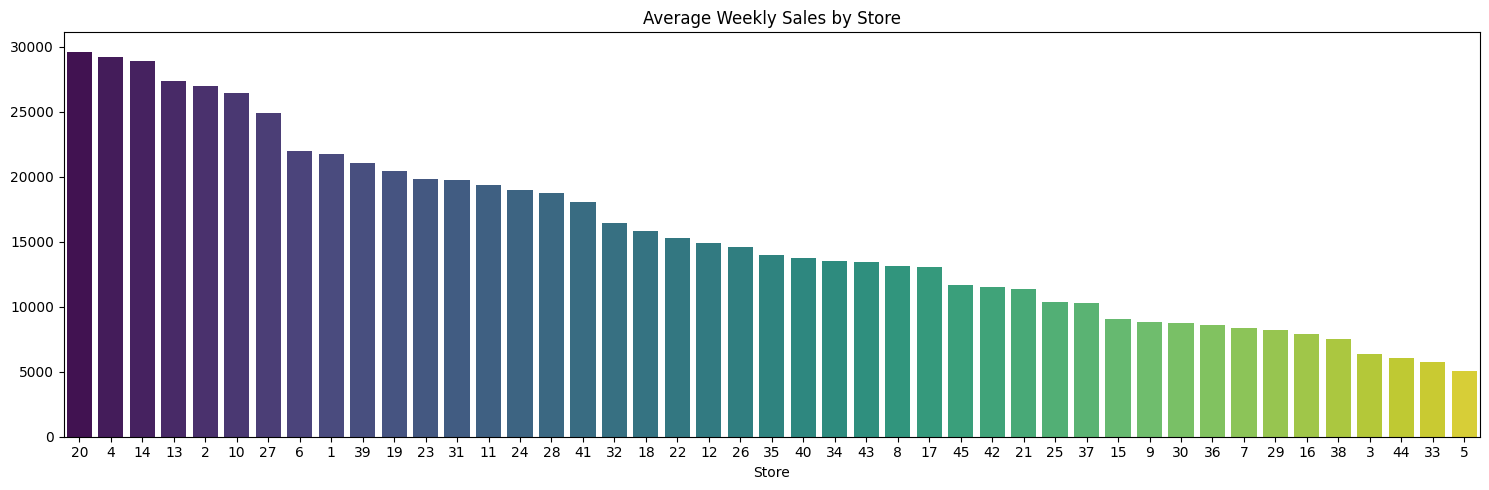

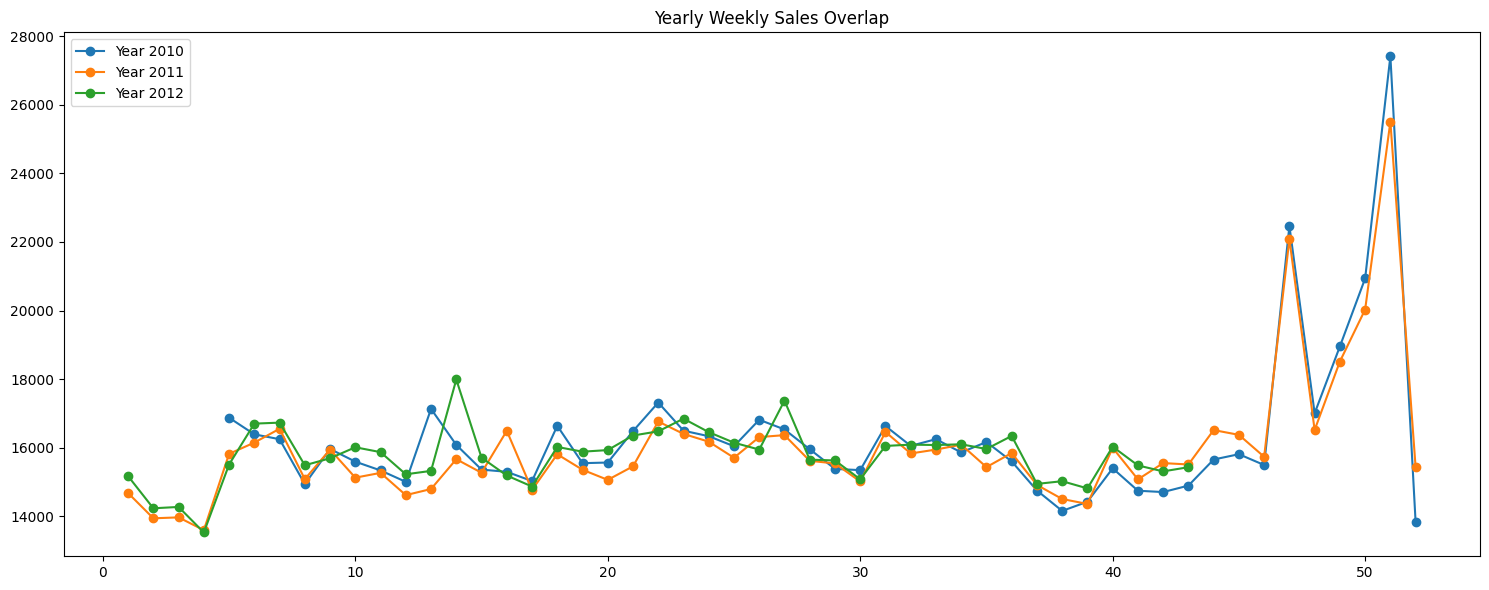

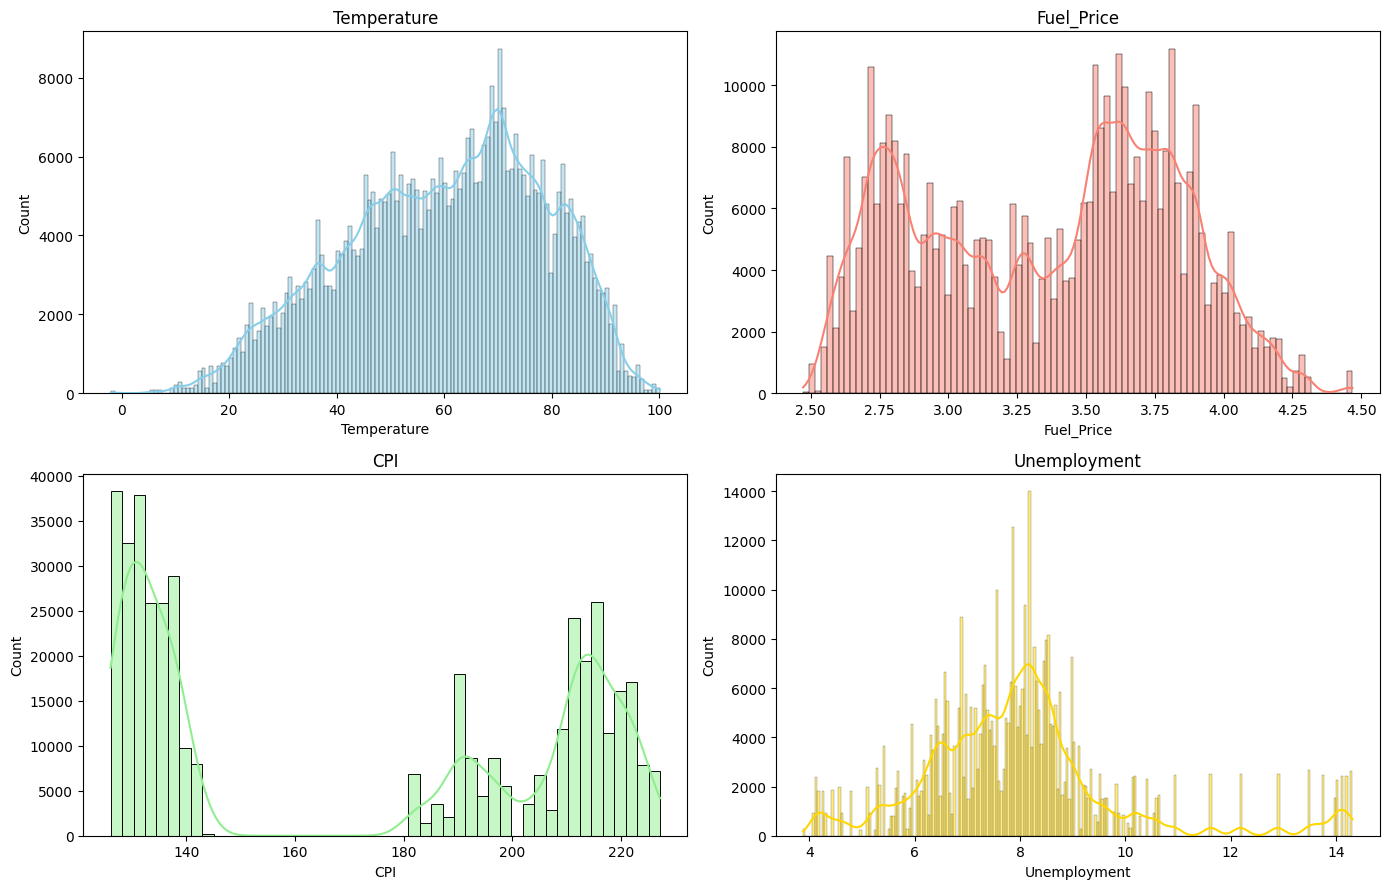

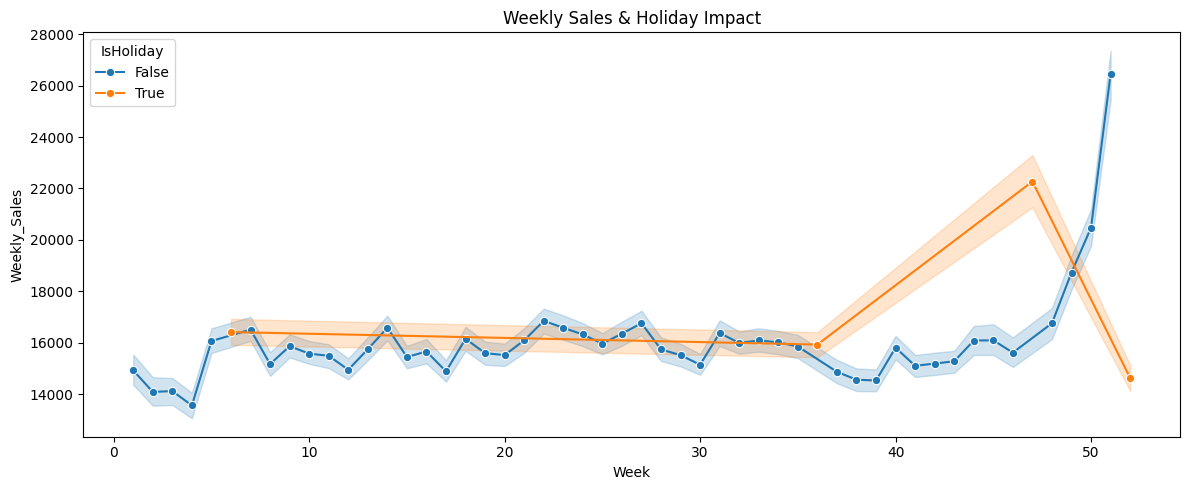

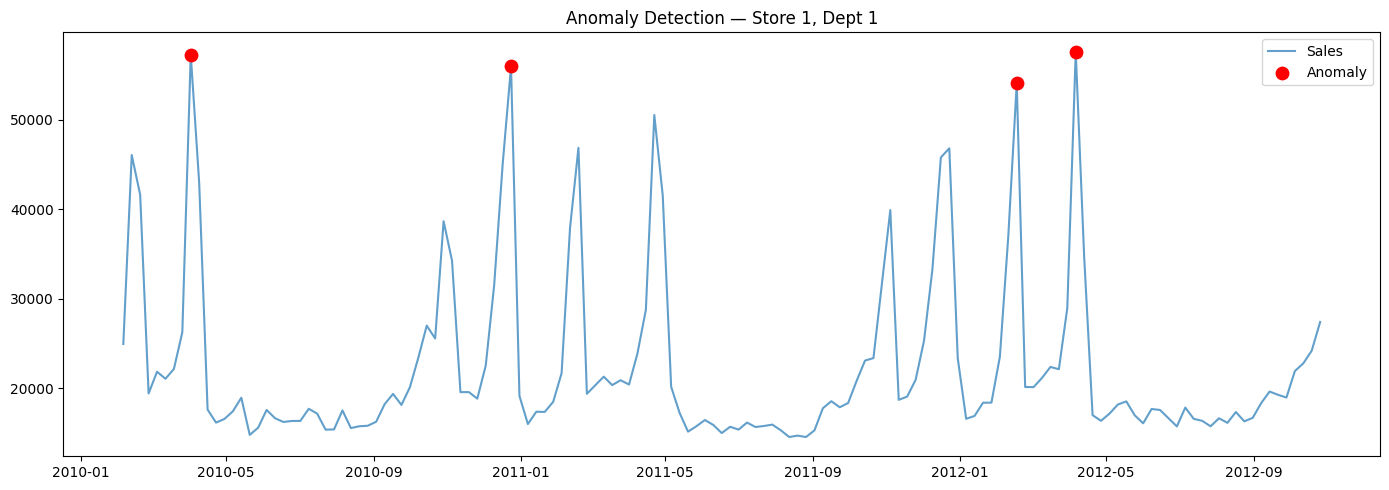

In [ ]:
class EDALayer:
    def __init__(self, df: pd.DataFrame):
        self.df = df.copy()
        self.df['Year'] = self.df['Date'].dt.year
        self.df['Week'] = self.df['Date'].dt.isocalendar().week.astype(int)

    def flag_anomalies(self, threshold: float = 3.0) -> pd.DataFrame:
        self.df['Sales_ZScore'] = self.df.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(
            lambda x: (x - x.mean()) / (x.std() + 1e-9)
        )
        self.df['Is_Anomaly'] = self.df['Sales_ZScore'].abs() > threshold
        print(f'Anomalies flagged: {self.df["Is_Anomaly"].sum():,}')
        return self.df

    def plot_store_rankings(self):
        plt.figure(figsize=(15, 5))
        perf = self.df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)
        sns.barplot(x=perf.index, y=perf.values, palette='viridis', order=perf.index)
        plt.title('Average Weekly Sales by Store')
        plt.tight_layout()
        plt.show()

    def plot_seasonality(self):
        plt.figure(figsize=(15, 6))
        for year in sorted(self.df['Year'].unique()):
            data = self.df[self.df['Year'] == year].groupby('Week')['Weekly_Sales'].mean()
            plt.plot(data.index, data.values, label=f'Year {year}', marker='o')
        plt.title('Yearly Weekly Sales Overlap')
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_external_factors(self):
        fig, axes = plt.subplots(2, 2, figsize=(14, 9))
        for ax, col, color in zip(axes.flat,
                                   ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment'],
                                   ['skyblue', 'salmon', 'lightgreen', 'gold']):
            sns.histplot(self.df[col], ax=ax, color=color, kde=True)
            ax.set_title(col)
        plt.tight_layout()
        plt.show()

    def plot_holiday_lift(self):
        plt.figure(figsize=(12, 5))
        sns.lineplot(data=self.df, x='Week', y='Weekly_Sales', hue='IsHoliday', marker='o')
        plt.title('Weekly Sales & Holiday Impact')
        plt.tight_layout()
        plt.show()

    def plot_anomaly_sample(self, store=1, dept=1):
        sample = self.df[(self.df['Store'] == store) & (self.df['Dept'] == dept)]
        plt.figure(figsize=(14, 5))
        plt.plot(sample['Date'], sample['Weekly_Sales'], label='Sales', alpha=0.7)
        anom = sample[sample['Is_Anomaly']]
        plt.scatter(anom['Date'], anom['Weekly_Sales'], color='red', s=80, label='Anomaly', zorder=5)
        plt.title(f'Anomaly Detection — Store {store}, Dept {dept}')
        plt.legend()
        plt.tight_layout()
        plt.show()

    def run_all_plots(self):
        self.plot_store_rankings()
        self.plot_seasonality()
        self.plot_external_factors()
        self.plot_holiday_lift()
        self.plot_anomaly_sample()

# EDA
eda = EDALayer(master_df)
master_df = eda.flag_anomalies()
eda.run_all_plots()

**Insights**

figure 1 :- Average Weekly sales by store

We analyzed performance across all 45 stores.
We found a significant gap between the top performers (Store 20, 4) and the lowest (Store 5),
which suggests that location or store 'Type' is a massive factor.

figure 2 :- Yealy Weekly Sales Overlap

By overlaying 2010, 2011, and 2012, we can see that retail is purely seasonal.
The spikes at Week 47 (Thanksgiving) and Week 51 (Christmas) are identical every year.
This proves we need Time-Series models like Prophet or XGBoost.

figure 3 :- Temperature Distribution

**Temperature**: Exhibits a classic unimodal seasonal trend, indicating that categorization into bins (Cold, Moderate, Hot, Freezing) will capture non-linear demand shifts.

figure 4 :- Fuel Price Distribution

**Fuel Price**: Displays a strong bimodal profile (peaks near $2.75 and $3.75), capturing localized economic shocks and fluctuations in regional shipping costs.

figure 5 :- CPI Distribution

**CPI**: Shows an extreme bimodal split with a gap between 145 and 180, indicating two starkly different regional customer bases. This supports our decision to use store segmentation.

figure 6 :- Unemployment Distribution

**Unemployment**: Follows a right-skewed log-normal shape, showing a concentration of healthy job markets along with localized regions facing high economic stress (up to 14%).

figure 7 :- Weekly Sales Trends & Holiday Impact

Heartbeat' of the retail cycle.
 The massive, consistent spikes in the final weeks of the year. What’s critical here is the 'Holiday Lift'. The delta between a standard week and a holiday week.
 Interestingly, the data shows that the boost often begins a week before the holiday itself.
 This identifies a 'Lead-Time' requirement for inventory; if a manager waits until the holiday week to restock, they’ve already missed the initial surge.

figure 8 :- Anamoly detection

demonstrates that our anomalies (highlighted with red markers) map precisely to major holiday periods (Easter, Thanksgiving, and Christmas). This proves that these outliers are not data errors but seasonal pulses, prompting us to retain them and capture them with dedicated calendar features.




---
## Feature Engineering

Temporal features, climate bins, sales lag, markdown aggregates.


In [ ]:

class FeatureEngineeringLayer:
    @staticmethod
    def temp_category(t):
        if pd.isna(t):
            return 'Unknown'
        if t <= 32:
            return 'Freezing'
        if t <= 52:
            return 'Cold'
        if t <= 78:
            return 'Moderate'
        return 'Hot'

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        out = df.sort_values(['Store', 'Dept', 'Date']).copy()
        out['Year'] = out['Date'].dt.year
        out['Month'] = out['Date'].dt.month
        out['Week'] = out['Date'].dt.isocalendar().week.astype(int)
        out['Temp_Category'] = out['Temperature'].apply(self.temp_category)
        out['Sales_Lag_1'] = out.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1).fillna(0)
        out['MD_Count'] = (out[MARKDOWN_COLS] > 0).sum(axis=1)
        out['Total_MD_Value'] = out[MARKDOWN_COLS].sum(axis=1)

        le = LabelEncoder()
        out['Type_Encoded'] = le.fit_transform(out['Type'])
        self.type_encoder = le
        return out

# Feature engineering
fe = FeatureEngineeringLayer()
master_df = fe.transform(master_df)
print('Engineered columns:', ['Temp_Category', 'Sales_Lag_1', 'MD_Count', 'Total_MD_Value', 'Type_Encoded'])
master_df[['Store', 'Dept', 'Date', 'Weekly_Sales', 'Sales_Lag_1', 'Temp_Category', 'Total_MD_Value']].head()


Engineered columns: ['Temp_Category', 'Sales_Lag_1', 'MD_Count', 'Total_MD_Value', 'Type_Encoded']


,Store,Dept,Date,Weekly_Sales,Sales_Lag_1,Temp_Category,Total_MD_Value
0,1,1,2010-02-05,24924.50,0.00,Cold,0.0
1,1,1,2010-02-12,46039.49,24924.50,Cold,0.0
2,1,1,2010-02-19,41595.55,46039.49,Cold,0.0
3,1,1,2010-02-26,19403.54,41595.55,Cold,0.0
4,1,1,2010-03-05,21827.90,19403.54,Cold,0.0


---
## Model Training

Trains four models:
- **K-Means** store segmentation (k=4)
- **SARIMA** statistical baseline on aggregate weekly sales
- **XGBoost** demand forecaster (time-based split)
- **Apriori** department association rules


In [ ]:

@dataclass
class TrainingArtifacts:
    store_profiles: pd.DataFrame
    kmeans: KMeans
    pca: PCA
    sarima_order: tuple
    sarima_seasonal: tuple
    xgb_model: xgb.XGBRegressor
    feature_cols: list
    metrics: dict
    association_rules: pd.DataFrame

class ModelTrainingLayer:
    FEATURE_COLS = [
        'Store', 'Dept', 'IsHoliday', 'Size', 'Type_Encoded',
        'CPI', 'Unemployment', 'Temperature', 'Fuel_Price',
        'Month', 'Week', 'Sales_Lag_1', 'Cluster',
        'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5'
    ]

    def train_segmentation(self, df: pd.DataFrame, n_clusters: int = 4):
        profiles = df.groupby('Store').agg(
            Weekly_Sales=('Weekly_Sales', 'mean'),
            Size=('Size', 'first'),
            Total_MD_Value=('Total_MD_Value', 'mean'),
            Unemployment=('Unemployment', 'mean'),
        ).reset_index()

        pt = PowerTransformer(method='yeo-johnson')
        scaler = StandardScaler()
        X = scaler.fit_transform(pt.fit_transform(profiles.drop('Store', axis=1)))

        pca = PCA(n_components=2, random_state=RANDOM_STATE)
        X_pca = pca.fit_transform(X)

        km = KMeans(n_clusters=n_clusters, init='k-means++', random_state=RANDOM_STATE)
        profiles['Cluster'] = km.fit_predict(X_pca)
        sil = silhouette_score(X_pca, profiles['Cluster'])
        print(f'Segmentation: k={n_clusters} | Silhouette={sil:.2f} | PCA var={pca.explained_variance_ratio_.sum():.1%}')
        display(profiles.groupby('Cluster').agg(store_count=('Store', 'count'),
                                                 avg_sales=('Weekly_Sales', 'mean'),
                                                 avg_size=('Size', 'mean')).round(2))
        return profiles, km, pca

    def train_sarima(self, sales_df: pd.DataFrame):
        ts = sales_df.groupby('Date')['Weekly_Sales'].sum().sort_index()
        auto = pm.auto_arima(ts, seasonal=True, m=52, stepwise=True,
                             max_p=2, max_q=2, max_P=1, max_Q=1,
                             suppress_warnings=True, error_action='ignore')
        model = SARIMAX(ts, order=auto.order, seasonal_order=auto.seasonal_order).fit(disp=False)
        print(f'SARIMA: {auto.order} x {auto.seasonal_order}')
        return auto.order, auto.seasonal_order, model

    def train_xgboost(self, df: pd.DataFrame, split_date: str = TEST_SPLIT_DATE):
        data = df.merge(self.store_profiles[['Store', 'Cluster']], on='Store', how='left')
        train = data[data['Date'] < split_date]
        test = data[data['Date'] >= split_date]

        X_train, y_train = train[self.FEATURE_COLS], train['Weekly_Sales']
        X_test, y_test = test[self.FEATURE_COLS], test['Weekly_Sales']

        model = xgb.XGBRegressor(
            n_estimators=100, learning_rate=0.1, max_depth=5,
            subsample=0.7, colsample_bytree=0.8,
            early_stopping_rounds=20, random_state=RANDOM_STATE, n_jobs=2
        )
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

        preds = model.predict(X_test)
        metrics = {
            'r2': float(r2_score(y_test, preds)),
            'mae': float(mean_absolute_error(y_test, preds)),
        }
        print(f"XGBoost: R2={metrics['r2']:.4f} | MAE={metrics['mae']:.2f}")
        self._test_frame = test.copy()
        self._test_preds = preds
        return model, metrics, test

    def train_association_rules(self, sales_df: pd.DataFrame, top_depts: int = 15):
        top = sales_df.groupby('Dept')['Weekly_Sales'].sum().nlargest(top_depts).index
        filtered = sales_df[sales_df['Dept'].isin(top)]
        txns = filtered.groupby(['Store', 'Date'])['Dept'].apply(
            lambda d: [str(x) for x in sorted(set(d))]
        ).tolist()

        enc = TransactionEncoder()
        mat = pd.DataFrame(enc.fit(txns).transform(txns), columns=enc.columns_)
        freq = apriori(mat, min_support=0.05, use_colnames=True)
        if freq.empty:
            return pd.DataFrame()
        rules = association_rules(freq, metric='confidence', min_threshold=0.8)
        rules = rules[rules['lift'] >= 2.0].sort_values('lift', ascending=False)
        print(f'Association rules found: {len(rules)}')
        return rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].reset_index(drop=True)

    def run(self, master_df, sales_df) -> TrainingArtifacts:
        self.store_profiles, self.kmeans, self.pca = self.train_segmentation(master_df)
        sarima_order, sarima_seasonal, _ = self.train_sarima(sales_df)
        xgb_model, metrics, _ = self.train_xgboost(master_df)
        rules = self.train_association_rules(sales_df)
        return TrainingArtifacts(
            store_profiles=self.store_profiles,
            kmeans=self.kmeans,
            pca=self.pca,
            sarima_order=sarima_order,
            sarima_seasonal=sarima_seasonal,
            xgb_model=xgb_model,
            feature_cols=self.FEATURE_COLS,
            metrics=metrics,
            association_rules=rules,
        )



# Model Training layer
trainer = ModelTrainingLayer()

In [ ]:
import gc

# Step 1 — Segmentation
trainer.store_profiles, trainer.kmeans, trainer.pca = trainer.train_segmentation(master_df)
gc.collect()

# Step 2 — SARIMA
sarima_order, sarima_seasonal, sarima_model = trainer.train_sarima(sales)
gc.collect()

Segmentation: k=4 | Silhouette=0.45 | PCA var=92.3%


,store_count,avg_sales,avg_size
Cluster,,,
0,5,13718.86,128743.00
1,11,13566.45,134844.55
2,13,8299.05,47435.77
3,16,23193.94,194954.50


SARIMA: (2, 0, 2) x (1, 0, 0, 52)


15

In [ ]:
# Step 3 — XGBoost
xgb_model, metrics, test_df = trainer.train_xgboost(master_df)
gc.collect()



XGBoost: R2=0.9709 | MAE=1812.97


37

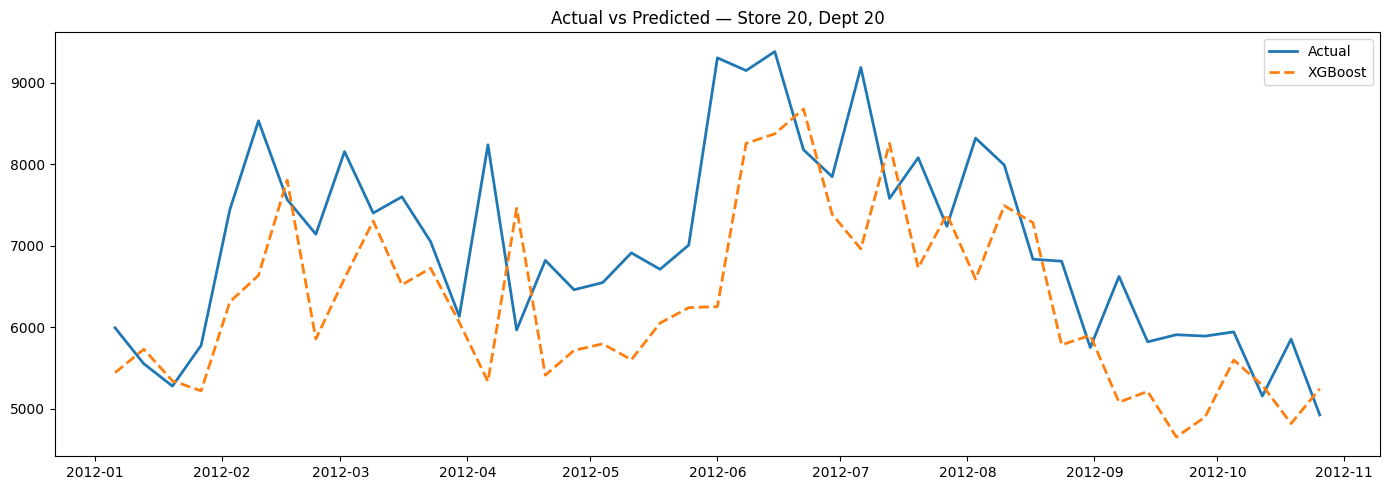

In [ ]:
# Visualize XGBoost performance (Store 20, Dept 20 case study)
plot_df = trainer._test_frame.copy()
plot_df['Predicted'] = trainer._test_preds
case = plot_df[(plot_df['Store'] == 20) & (plot_df['Dept'] == 20)].sort_values('Date')
plt.figure(figsize=(14, 5))
plt.plot(case['Date'], case['Weekly_Sales'], label='Actual', linewidth=2)
plt.plot(case['Date'], case['Predicted'], label='XGBoost', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted — Store 20, Dept 20')
plt.legend()
plt.tight_layout()
plt.show()


**Insight :**
the trained XGBoost model closely tracks the volatile peaks and valleys of our out-of-sample validation data. By integrating localized economic, climate, and categorical features, the model captures complex seasonal transitions, proving its viability as an enterprise demand forecasting tool.


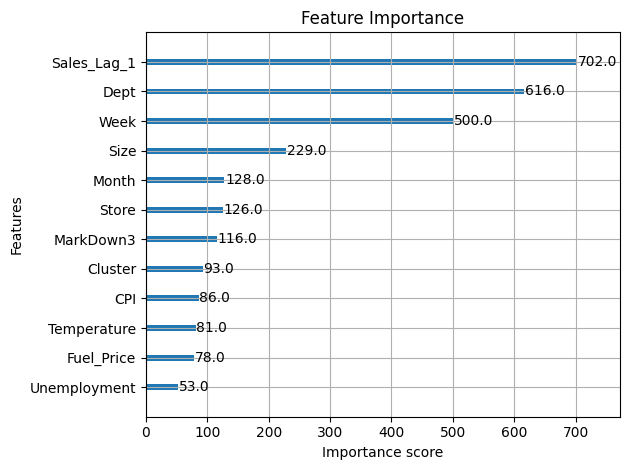

In [ ]:
xgb.plot_importance(xgb_model, max_num_features=12)
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

### The Dominant Drivers: Department & Momentum

**Inference:** Sales_Lag_1 (702) and Dept (616) are top predictors.

This shows that "What" is being sold is more important than "Where" it is being sold. The high score for Sales_Lag_1 indicates strong Recency Bias—the best predictor of next week's sales is how much we sold last week.

**Strategy:** we should prioritize department-level inventory planning over store-wide general allocations.

------------------------------------------------------------

###The Power of Seasonality

**Inference:** Week (500) significantly outweighs Month (128).

Retail is highly granular. A "Month" is too broad; the model is finding specific "Weeks" (like the week before Thanksgiving or the Super Bowl) that trigger massive shifts in behavior.

**Strategy:** Promotions and staffing should be planned on a weekly sprint basis rather than monthly targets.

------------------------------------------------------------

###The "Environmental Context" (Surprising Insight)

**Inference:** Temperature (81) and Fuel_Price (78) are more influential than Unemployment.

It suggests that immediate environmental factors (weather and gas prices) have a more direct, week-to-week impact on shopping trips than broader economic indicators like CPI or Unemployment.

**Strategy:** Use "Weather-Triggered Marketing." For example, if Temperature is predicted to drop (high feature importance), automatically trigger stock increases for heaters or winter apparel in those specific stores.

------------------------------------------------------------

###Markdowns: Quality over Quantity
**Inference:** MarkDown3 (116) is the most influential promotion, outperforming the other four markdown types.

For MarkDown3, the model has learned that this specific type of discount creates the most significant "lift" in sales volume.

**Strategy:** Optimize the "Promotional Mix." If the budget is limited, investing in MarkDown3-style events yields a higher return on sales than spreading the budget across MD2 or MD4.

## **Market Basket Analysis**

Now that we’ve successfully segmented our stores and built a predictive engine that highlights Department type as a primary sales driver, we need to look deeper into the transaction level. Market Basket Analysis, we will uncover how these departments interact within a single shopping trip to optimize store layouts and cross-promotional strategies."

**How Does Market Basket Analysis Work?**

Collect data on customer transactions, such as the items purchased in each transaction, the time and date of the transaction, and any other relevant information.

Clean and preprocess the data, removing any irrelevant information, handling missing values, and converting the data into a suitable format for analysis.

Use association rules mining algorithms such as Apriori or FP-Growth to identify frequent item sets, sets of items often appearing together in a transaction.

Calculate the support and confidence for each frequent itemset, expressing the likelihood of one item being purchased given the purchase of another item.

Generate association rules based on the frequent itemsets and their corresponding support and confidence values. Association rules indicate the likelihood of purchasing one item given the purchase of another item.

Interpret the results of the market basket analysis, identifying frequent purchases, assessing the strength of the association between items, and uncovering other relevant insights into customer behavior and preferences.

Use the insights from the market basket analysis to inform business decisions such as product recommendations, store layout optimization, and targeted marketing campaigns.

**Algorithms Used in Market Basket Analysis**

We have used Apriori Algorithm to do the Market Basket Analysis


**Objective:**

The goal is to uncover associations between different Departments across the retail network. By identifying which departments tend to have peak sales together, we can develop actionable strategies for product placement, cross-selling, and targeted marketing.



In [ ]:
# Step 4 — Association rules, currently we don't run it crash the colab ram
import gc

print('Starting association rules')
rules = trainer.train_association_rules(sales)
gc.collect()

Starting association rules


---
## Inference Layer

Score the holdout period and produce batch forecast outputs with metadata.


In [ ]:

class InferenceLayer:
    def __init__(self, artifacts: TrainingArtifacts):
        self.artifacts = artifacts

    def predict(self, df: pd.DataFrame) -> pd.DataFrame:
        scored = df.merge(self.artifacts.store_profiles[['Store', 'Cluster']], on='Store', how='left')
        scored = scored.copy()
        scored['point_forecast'] = self.artifacts.xgb_model.predict(scored[self.artifacts.feature_cols])
        scored['forecast_error'] = scored['Weekly_Sales'] - scored['point_forecast']
        scored['abs_pct_error'] = (scored['forecast_error'].abs() /
                                   scored['Weekly_Sales'].clip(lower=1)) * 100
        return scored

    def export_forecasts(self, scored: pd.DataFrame, path: str | None = None) -> pd.DataFrame:
        out = scored[['Store', 'Dept', 'Date', 'Weekly_Sales', 'point_forecast',
                       'forecast_error', 'Cluster']].copy()
        out['model'] = 'xgboost'
        out['scored_at'] = datetime.now(timezone.utc).isoformat()
        if path:
            out.to_csv(path, index=False)
            print(f'Forecasts saved to {path}')
        return out

# Run Layer 7 — score holdout rows
inference = InferenceLayer(artifacts)
holdout = master_df[master_df['Date'] >= TEST_SPLIT_DATE].copy()
forecasts = inference.predict(holdout)
export_path = os.path.join(DATA_DIR, 'batch_forecasts_colab.csv')
forecast_output = inference.export_forecasts(forecasts, export_path)

print(f'Holdout rows scored: {len(forecast_output):,}')
print(f"Mean abs % error: {forecast_output['abs_pct_error'].mean():.1f}%")
forecast_output.head()


---
## Pipeline Orchestration

Single entry point that runs all layers sequentially and returns a structured result.


In [ ]:

@dataclass
class PipelineResult:
    run_id: str
    master_df: pd.DataFrame
    artifacts: TrainingArtifacts
    forecasts: pd.DataFrame
    validation: ValidationResult
    metrics: dict

class RetailAnalyticsPipeline:
    """End-to-end orchestrator for all 8 layers."""

    def __init__(self, data_dir: str):
        self.data_dir = data_dir
        self.run_id = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')

    def run(self, skip_eda_plots: bool = True) -> PipelineResult:
        print('=' * 60)
        print(f'Pipeline run_id: {self.run_id}')
        print('=' * 60)

        # Layer 1 — Ingestion
        print('\n[1/8] Data Ingestion')
        raw = DataIngestionLayer(self.data_dir).load()

        # Layer 2 — Validation
        print('\n[2/8] Data Validation')
        val = DataValidationLayer().validate_raw(raw['sales'], raw['stores'], raw['features'])
        val.report()

        # Layer 3 — Preprocessing
        print('\n[3/8] Data Preprocessing')
        master = DataPreprocessingLayer().run(raw['sales'], raw['stores'], raw['features'])
        DataValidationLayer().validate_master(master).report()

        # Layer 4 — EDA
        print('\n[4/8] EDA')
        eda_layer = EDALayer(master)
        master = eda_layer.flag_anomalies()
        if not skip_eda_plots:
            eda_layer.run_all_plots()
        else:
            print('  (plots skipped — set skip_eda_plots=False to render)')

        # Layer 5 — Feature Engineering
        print('\n[5/8] Feature Engineering')
        master = FeatureEngineeringLayer().transform(master)

        # Layer 6 — Model Training
        print('\n[6/8] Model Training')
        artifacts = ModelTrainingLayer().run(master, raw['sales'])

        # Layer 7 — Inference
        print('\n[7/8] Inference')
        holdout = master[master['Date'] >= TEST_SPLIT_DATE]
        forecasts = InferenceLayer(artifacts).predict(holdout)

        # Layer 8 — Summary
        print('\n[8/8] Pipeline Complete')
        summary = {
            'run_id': self.run_id,
            'rows': len(master),
            'stores': master['Store'].nunique(),
            'forecast_r2': artifacts.metrics['r2'],
            'forecast_mae': artifacts.metrics['mae'],
            'sarima': f'{artifacts.sarima_order}x{artifacts.sarima_seasonal}',
            'association_rules': len(artifacts.association_rules),
            'anomalies': int(master['Is_Anomaly'].sum()),
        }
        print(json.dumps(summary, indent=2))

        manifest_path = os.path.join(self.data_dir, f'pipeline_manifest_{self.run_id}.json')
        with open(manifest_path, 'w') as f:
            json.dump(summary, f, indent=2)
        print(f'Manifest saved: {manifest_path}')

        return PipelineResult(
            run_id=self.run_id,
            master_df=master,
            artifacts=artifacts,
            forecasts=forecasts,
            validation=val,
            metrics=artifacts.metrics,
        )

# ── Run full pipeline (set skip_eda_plots=False to show all charts) ──
pipeline = RetailAnalyticsPipeline(DATA_DIR)
result = pipeline.run(skip_eda_plots=True)


## **Summary of Insights**



we synthesize the findings from our Clustering, Forecasting, and Market Basket Analysis to create a unified retail strategy.

**Store Segmentation:** We identified 4 distinct store clusters. Strategy should shift from "One-Size-Fits-All" to persona-based management.

**Sales Drivers:** Our XGBoost model revealed that Department Type and Previous week's sales are more predictive than specific holidays.

**Customer Behavior:** Market Basket Analysis highlighted specific departmental synergies that are currently underutilized in store layouts.



**Operational Efficiency (Based on XGBoost)**

- Department-Centric Inventory Scaling: Since Department is the #1 driver, inventory planning must be decentralized. Instead of a "store-wide" increase, resources should be shifted dynamically to high-performing departments (like Grocery or Electronics) based on their specific historical trends.

- Momentum-Based Labor Sprinting: Because Sales_Lag_1 is a dominant feature, the model proves that "success breeds success." Use the previous week's performance as a high-confidence trigger to adjust staffing levels for the following week. If a department is trending upward, staff up immediately.


**Revenue Growth (Based on MBA)**

- Adjacency Optimization: Place associated departments (identified via Lift) near each other. For "Golden Pairs" located far apart, implement "Cross-Category End-caps" to capture impulse sales.

- Strategic Markdowns: Apply discounts to "Anchor" departments (Antecedents) to pull traffic into associated "High-Margin" departments (Consequents).


**Store-Specific Strategy (Based on Clustering)**

By segmenting our 45 locations into four distinct personas, we move away from a "one-size-fits-all" approach to a localized, data-driven management strategy:

####Cluster 3 (Mega-Flagship Centers):

- Strategy: Expand the "Store-in-Store" concept and premium showrooms for high-margin electronics and home goods.

- Action: Capitalize on the massive footprint (~195k sq ft) to stock bulky, high-value inventory (like outdoor furniture) that smaller clusters cannot accommodate.

####Cluster 1 (High-Unemployment Stability Stores):

- Strategy: Pivot to a "Value-First" assortment by increasing the ratio of Private Label (Great Value) brands.

- Action: Align markdown cycles and heavy promotions with economic cycles (e.g., beginning-of-month surges) to cater to price-sensitive shoppers facing higher economic pressure.

####Cluster 0 (Niche Economic Strongholds):

- Strategy: Focus on Premiumization and Lifestyle marketing rather than budget-focused messaging.

- Action: Stock higher-margin, organic, or "top-tier" product variants, as the low unemployment rate (5.66%) in these regions indicates a demographic with higher disposable income.

####Cluster 2 (Small-Format Neighborhood Essentials):

- Strategy: Optimize for "High-Velocity Convenience" by removing slow-moving, bulky items.

- Action: Reconfigure the layout to prioritize "Grab-and-Go" sections, focusing strictly on daily essentials that drive quick, high-frequency foot traffic.